In [1]:
import pandas as pd

# df = pd.read_csv('/mnt/c/Users/cic/Downloads/pathologie.csv',sep=";")
df = pd.read_csv('/home/syphax/GitHub/Lily/app_sante/data/raw/pathologie.csv',sep=";")
#types des colonnes
#df.info()
df.describe(include="O")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/syphax/GitHub/Lily/app_sante/data/raw/pathologie.csv'

In [33]:
df.describe(include="O")


,patho_niv1,patho_niv2,patho_niv3,top,cla_age_5,Niveau prioritaire,libelle_classe_age,libelle_sexe
count,608580,545076,470988,608580,608580,600642,608580,608580
unique,18,48,61,79,21,5,21,3
top,Maladies cardioneurovasculaires,Maladies inflammatoires chroniques,Total consommants tous régimes,POP_TOT_IND,80-84,"2,3",de 80 à 84 ans,tous sexes
freq,119070,39690,7938,7938,28980,222264,28980,209034


In [34]:
#tri par année desc
df.sort_values(by="dept",ascending=False)
#df['dept'].unique()

,annee,patho_niv1,patho_niv2,patho_niv3,top,cla_age_5,sexe,region,dept,Ntop,Npop,prev,Niveau prioritaire,libelle_classe_age,libelle_sexe,tri
608553,2017,Maladies cardioneurovasculaires,Accident vasculaire cérébral,Séquelle d'accident vasculaire cérébral,MCV_AVC_CHR,00-04,9,76,999,200.0,295500,0.067,3,de 0 à 4 ans,tous sexes,67.0
28,2019,Total consommants tous régimes,Total consommants tous régimes,Total consommants tous régimes,POP_TOT_IND,90-94,9,76,999,79050.0,79050,100.000,NaN,de 90 à 94 ans,tous sexes,NaN
608579,2017,Maladies cardioneurovasculaires,Accident vasculaire cérébral,Séquelle d'accident vasculaire cérébral,MCV_AVC_CHR,10-14,2,76,999,60.0,157020,0.036,3,de 10 à 14 ans,femmes,67.0
130444,2021,Insuffisance rénale chronique terminale,Transplantation rénale,Transplantation rénale,IRT_TRE_AIG,35-39,1,76,999,NaN,181700,NaN,"2,3",de 35 à 39 ans,hommes,24.0
130439,2020,Maladies psychiatriques,Troubles psychotiques,Troubles psychotiques,PSY_PSC_IND,tsage,1,76,999,26090.0,2794470,0.934,"2,3",tous âges,hommes,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205988,2023,Insuffisance rénale chronique terminale,Transplantation rénale,Transplantation rénale,IRT_TRE_AIG,20-24,1,76,9,NaN,3820,NaN,"2,3",de 20 à 24 ans,hommes,24.0
565051,2023,Maladies du foie ou du pancréas (hors mucovisc...,Maladies du foie ou du pancréas (hors mucovisc...,Maladies du foie ou du pancréas (hors mucovisc...,MFP_CAT_EXC,55-59,1,76,9,100.0,5190,1.947,"1,2,3",de 55 à 59 ans,hommes,6.0
271513,2019,Total consommants tous régimes,Total consommants tous régimes,Total consommants tous régimes,POP_TOT_IND,80-84,9,76,9,5530.0,5530,100.000,NaN,de 80 à 84 ans,tous sexes,NaN
336900,2017,Maladies inflammatoires ou rares ou infection VIH,Maladies rares,Mucoviscidose,RAR_MUC_IND,65-69,1,76,9,NaN,5390,NaN,3,de 65 à 69 ans,hommes,78.0


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
# Afficher les types de colonnes et les valeurs manquantes
df.isna().sum()
#-> je dois supp les colonnes "tri" et "niveau prioritaire","sexe"(double),depart N°999/ patho_niv2 -->10% NAN, patho_niv3-->22%NAN (a voir apres supp des lignes non malades)

annee                      0
patho_niv1                 0
patho_niv2             63504
patho_niv3            137592
top                        0
cla_age_5                  0
sexe                       0
region                     0
dept                       0
Ntop                  184058
Npop                       0
prev                  184058
Niveau prioritaire      7938
libelle_classe_age         0
libelle_sexe               0
tri                     7938
dtype: int64

In [37]:
# supp les colonnes "tri", "niveau prioritaire","patho_niv2","patho_niv3" /supp des lignes de valeurs null Ntop(30%)

df=df.drop(["tri", "Niveau prioritaire", "sexe","patho_niv2","patho_niv3"], axis=1).dropna(subset=["Ntop"])
#Verif
df.isna().sum()
df

,annee,patho_niv1,top,cla_age_5,region,dept,Ntop,Npop,prev,libelle_classe_age,libelle_sexe
0,2019,Total consommants tous régimes,POP_TOT_IND,80-84,76,12,11410.0,11410,100.000,de 80 à 84 ans,tous sexes
1,2019,Total consommants tous régimes,POP_TOT_IND,80-84,76,31,32170.0,32170,100.000,de 80 à 84 ans,tous sexes
2,2019,Total consommants tous régimes,POP_TOT_IND,80-84,76,34,33910.0,33910,100.000,de 80 à 84 ans,tous sexes
3,2019,Total consommants tous régimes,POP_TOT_IND,80-84,76,81,14240.0,14240,100.000,de 80 à 84 ans,tous sexes
4,2019,Total consommants tous régimes,POP_TOT_IND,85-89,76,11,3920.0,3920,100.000,de 85 à 89 ans,hommes
...,...,...,...,...,...,...,...,...,...,...,...
608569,2017,Maladies cardioneurovasculaires,MCV_AVC_CHR,10-14,76,34,20.0,32020,0.053,de 10 à 14 ans,hommes
608571,2017,Maladies cardioneurovasculaires,MCV_AVC_CHR,10-14,76,999,90.0,164480,0.057,de 10 à 14 ans,hommes
608573,2017,Maladies cardioneurovasculaires,MCV_AVC_CHR,10-14,76,31,10.0,36490,0.033,de 10 à 14 ans,femmes
608575,2017,Maladies cardioneurovasculaires,MCV_AVC_CHR,10-14,76,34,10.0,30910,0.039,de 10 à 14 ans,femmes


In [38]:
#suppression par filtrage du departement 999(personnes non residents ou adresse non connue) -> df2
df=df[df['dept'] != 999]
df
#verif 
df['dept'].unique()

array([12, 31, 34, 81, 11, 30, 46, 48, 65, 82,  9, 32, 66])

In [39]:
#Sommer Npop et Ntop par année et par département,par age et par patho en exluant le sexe pour pouvoir recalculer la prévalence (prev) de chaque patho_niv1 sans distinction de genre.
data=df.groupby(['annee', 'dept', 'libelle_classe_age','patho_niv1'], as_index=False).agg({
    'Npop': 'sum',
    'Ntop': 'sum'
})
data

,annee,dept,libelle_classe_age,patho_niv1,Npop,Ntop
0,2015,9,de 0 à 4 ans,Affections de longue durée (dont 31 et 32) pou...,13610,120.0
1,2015,9,de 0 à 4 ans,Hospitalisations hors pathologies repérées (av...,13610,3460.0
2,2015,9,de 0 à 4 ans,Maladies cardioneurovasculaires,20410,80.0
3,2015,9,de 0 à 4 ans,Maladies inflammatoires ou rares ou infection VIH,20400,40.0
4,2015,9,de 0 à 4 ans,Maladies neurologiques,23890,90.0
...,...,...,...,...,...,...
38871,2023,82,tous âges,"Pas de pathologie repérée, traitement, materni...",533780,283360.0
38872,2023,82,tous âges,Total consommants tous régimes,533780,533780.0
38873,2023,82,tous âges,Traitements antalgiques ou anti-inflammatoires...,533780,8040.0
38874,2023,82,tous âges,Traitements du risque vasculaire (hors patholo...,1601340,159500.0


In [40]:
# Calcul de la prévalence spécifique à chaque groupe sans distinction de genre.
data['prev_calculee'] = ((data['Ntop'] / data['Npop'])*100).round(2)
data

,annee,dept,libelle_classe_age,patho_niv1,Npop,Ntop,prev_calculee
0,2015,9,de 0 à 4 ans,Affections de longue durée (dont 31 et 32) pou...,13610,120.0,0.88
1,2015,9,de 0 à 4 ans,Hospitalisations hors pathologies repérées (av...,13610,3460.0,25.42
2,2015,9,de 0 à 4 ans,Maladies cardioneurovasculaires,20410,80.0,0.39
3,2015,9,de 0 à 4 ans,Maladies inflammatoires ou rares ou infection VIH,20400,40.0,0.20
4,2015,9,de 0 à 4 ans,Maladies neurologiques,23890,90.0,0.38
...,...,...,...,...,...,...,...
38871,2023,82,tous âges,"Pas de pathologie repérée, traitement, materni...",533780,283360.0,53.09
38872,2023,82,tous âges,Total consommants tous régimes,533780,533780.0,100.00
38873,2023,82,tous âges,Traitements antalgiques ou anti-inflammatoires...,533780,8040.0,1.51
38874,2023,82,tous âges,Traitements du risque vasculaire (hors patholo...,1601340,159500.0,9.96


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer pour le département 31, l'année 2023 et la population globale
df_31_2023 = data[(data['dept'] == 31) & 
                (data['annee'] == 2023)]
# Trier par prévalence pour un meilleur rendu visuel
df_31_2023 = df_31_2023.sort_values(by='prev_calculee', ascending=False)


/tmp/ipykernel_45552/1082314866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_31_2023,


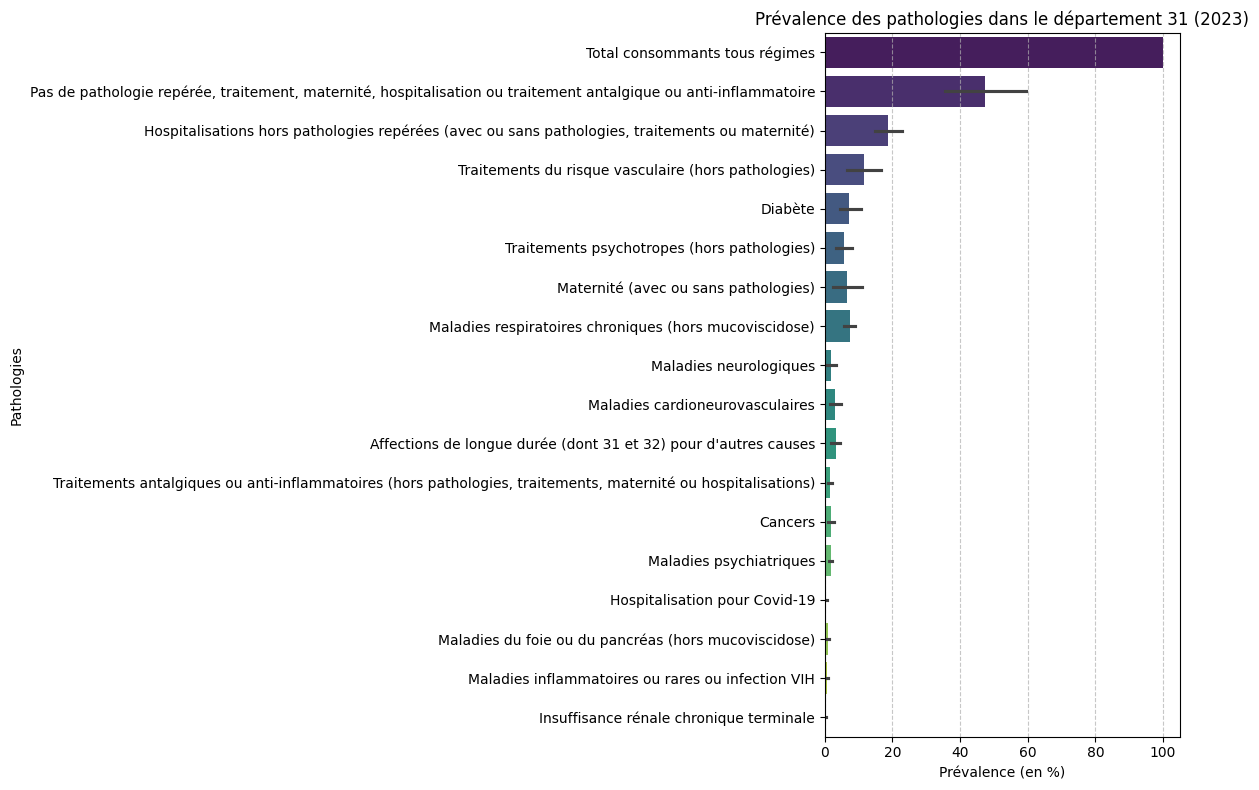

In [42]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_31_2023, 
            x='prev_calculee', 
            y='patho_niv1', 
            palette='viridis')

plt.title('Prévalence des pathologies dans le département 31 (2023)')
plt.xlabel('Prévalence (en %)')
plt.ylabel('Pathologies')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [43]:
data["patho_niv1"].unique()

array(["Affections de longue durée (dont 31 et 32) pour d'autres causes",
       'Hospitalisations hors pathologies repérées (avec ou sans pathologies, traitements ou maternité)',
       'Maladies cardioneurovasculaires',
       'Maladies inflammatoires ou rares ou infection VIH',
       'Maladies neurologiques', 'Maladies psychiatriques',
       'Maladies respiratoires chroniques (hors mucoviscidose)',
       'Pas de pathologie repérée, traitement, maternité, hospitalisation ou traitement antalgique ou anti-inflammatoire',
       'Total consommants tous régimes',
       'Traitements antalgiques ou anti-inflammatoires (hors pathologies, traitements, maternité ou hospitalisations)',
       'Cancers', 'Diabète',
       'Traitements psychotropes (hors pathologies)',
       'Maladies du foie ou du pancréas (hors mucoviscidose)',
       'Maternité (avec ou sans pathologies)',
       'Traitements du risque vasculaire (hors pathologies)',
       'Insuffisance rénale chronique terminale',
    

In [47]:
# 1. Liste des libellés à exclure
exclusions =["Total consommants tous régimes","Pas de pathologie repérée, traitement, maternité, hospitalisation ou traitement antalgique ou anti-inflammatoire"]

data[~data['patho_niv1'].isin(exclusions)]

data_clean=data[~data['patho_niv1'].isin(exclusions)]
data_clean

,annee,dept,libelle_classe_age,patho_niv1,Npop,Ntop,prev_calculee
0,2015,9,de 0 à 4 ans,Affections de longue durée (dont 31 et 32) pou...,13610,120.0,0.88
1,2015,9,de 0 à 4 ans,Hospitalisations hors pathologies repérées (av...,13610,3460.0,25.42
2,2015,9,de 0 à 4 ans,Maladies cardioneurovasculaires,20410,80.0,0.39
3,2015,9,de 0 à 4 ans,Maladies inflammatoires ou rares ou infection VIH,20400,40.0,0.20
4,2015,9,de 0 à 4 ans,Maladies neurologiques,23890,90.0,0.38
...,...,...,...,...,...,...,...
38869,2023,82,tous âges,Maladies respiratoires chroniques (hors mucovi...,533780,35900.0,6.73
38870,2023,82,tous âges,Maternité (avec ou sans pathologies),274820,8060.0,2.93
38873,2023,82,tous âges,Traitements antalgiques ou anti-inflammatoires...,533780,8040.0,1.51
38874,2023,82,tous âges,Traitements du risque vasculaire (hors patholo...,1601340,159500.0,9.96


In [48]:
#verif
data_clean["patho_niv1"].unique()


array(["Affections de longue durée (dont 31 et 32) pour d'autres causes",
       'Hospitalisations hors pathologies repérées (avec ou sans pathologies, traitements ou maternité)',
       'Maladies cardioneurovasculaires',
       'Maladies inflammatoires ou rares ou infection VIH',
       'Maladies neurologiques', 'Maladies psychiatriques',
       'Maladies respiratoires chroniques (hors mucoviscidose)',
       'Traitements antalgiques ou anti-inflammatoires (hors pathologies, traitements, maternité ou hospitalisations)',
       'Cancers', 'Diabète',
       'Traitements psychotropes (hors pathologies)',
       'Maladies du foie ou du pancréas (hors mucoviscidose)',
       'Maternité (avec ou sans pathologies)',
       'Traitements du risque vasculaire (hors pathologies)',
       'Insuffisance rénale chronique terminale',
       'Hospitalisation pour Covid-19'], dtype=object)

In [ ]:
#enregistrer le csv clean
data_clean.to_csv("../data/processed/fichier_final.csv", index=False)
